# 01. Optimizer Foundations: From SGD to Adam & AMSGrad

This notebook explores the comparative mechanics of first-order stochastic optimizers:
- **SGD**: Vanilla gradient descent
- **SGD (Momentum)**: First-moment velocity accumulation
- **AdaGrad**: Cumulative sum coordinate scaling ($G_t = G_{t-1} + g_t^2$)
- **RMSProp**: Exponential moving average coordinate scaling ($v_t = \beta v_{t-1} + (1-\beta)g_t^2$)
- **Adam**: Bias-corrected first ($m_t$) and second ($v_t$) moments
- **AMSGrad**: Monotonic running maximum second moment ($\hat{v}_t = \max(\hat{v}_{t-1}, v_t)$)

---


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from src.optimizers import SGD, AdaGrad, RMSProp, Adam, AMSGrad
from src.benchmarks.toy_functions import QuadraticBowl, Rosenbrock, Himmelblau
from src.visualization.trajectory_plotter import plot_2d_trajectories
from src.visualization.convergence_curves import plot_loss_curves


## 1. Ill-Conditioned Quadratic Bowl ($\kappa = 50$)
$$f(x, y) = \frac{1}{2} x^2 + \frac{1}{2} \kappa y^2$$
Observe how vanilla SGD oscillates across the steep valley walls while Adam and AMSGrad normalize coordinate scaling to traverse directly to the minimum.


In [2]:
quad = QuadraticBowl(kappa=50.0)
x0 = np.array([-2.5, 2.5])

opts = {
    "SGD": SGD(lr=0.02),
    "SGD (Mom)": SGD(lr=0.02, momentum=0.9),
    "AdaGrad": AdaGrad(lr=0.3),
    "RMSProp": RMSProp(lr=0.05, beta=0.9),
    "Adam": Adam(lr=0.1, beta1=0.9, beta2=0.999),
    "AMSGrad": AMSGrad(lr=0.1, beta1=0.9, beta2=0.999),
}

trajs, losses = {}, {}
for name, opt in opts.items():
    x = x0[None, :].copy()
    tr, ls = [x[0].copy()], [float(quad.evaluate(x)[0])]
    for _ in range(150):
        g = np.clip(quad.grad(x), -100, 100)
        x = opt.step(x, g)
        tr.append(x[0].copy())
        ls.append(float(quad.evaluate(x)[0]))
    trajs[name] = np.array(tr)
    losses[name] = ls

plot_2d_trajectories(quad, trajs, x_range=(-3, 3), y_range=(-3, 3), title="Quadratic Bowl Trajectories")


## 2. Convergence Comparison
Comparing loss trajectories across iterations on the Quadratic Bowl:


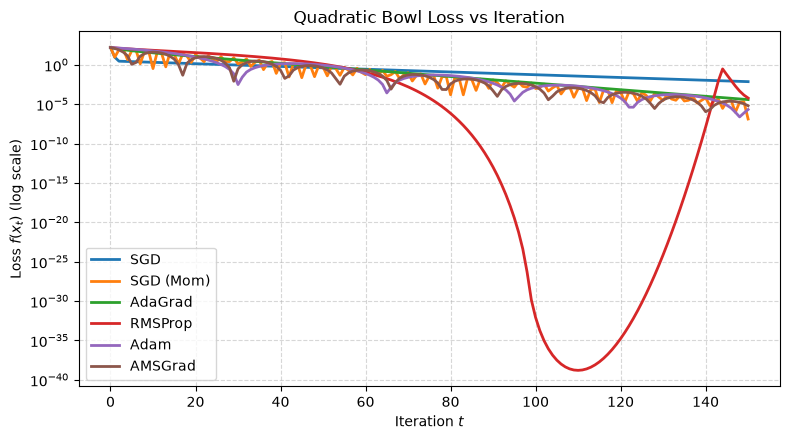

In [3]:
plt.figure(figsize=(8, 4.5))
for name, ls in losses.items():
    plt.semilogy(ls, label=name, linewidth=2)
plt.xlabel(r"Iteration $t$")
plt.ylabel(r"Loss $f(x_t)$ (log scale)")
plt.title(r"Quadratic Bowl Loss vs Iteration")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## 3. What to Notice
1. **Coordinate Normalization**: Dividing by $\sqrt{v_t} + \epsilon$ dampens oscillations along steep directions (large gradients) while accelerating progress along flat directions (small gradients).
2. **Bias Correction**: At early steps $t=1, 2$, debiasing prevents updates from artificially shrinking due to zero-initialization of moments.
3. **Behavior on Ravines**: Momentum damps directional oscillation, but coordinate-wise adaptive methods achieve substantially faster isotropic descent.
